## 1. Install requird libraries

In [5]:
# End to end explainable AI ( XAI) demo
# Use case Customer required  -telecom
# !pip install shap line
# !pip install lime

## # 2. Import libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import shap
from lime.lime_tabular import LimeTabularExplainer

import warnings
warnings.filterwarnings(action ='ignore')

## 3. Load Practical Dataset
### dataset : tele customer churn

In [7]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. data Preprocessing

In [8]:
df.drop("customerID", axis =1, inplace = True)


In [9]:
# convert totalCharges to Numeric
df["TotalCharges"] = pd.to_numeric (df ["TotalCharges"],errors ="coerce")
df.dropna(inplace=True)

In [10]:
# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes (include = "object").columns:
  df[col] = le.fit_transform(df[col])
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0


In [11]:
df.shape

(7032, 20)

In [12]:
X = df.drop("Churn", axis =1)
y = df["Churn"]

features_names =X.columns.tolist()

## 5. Train Test Split

In [13]:
X_train , X_test, y_train, y_test = train_test_split(X,y,test_size =0.2, random_state =42)
X_train = X_train.reset_index(drop = True)
X_test = X_test.reset_index (drop = True)


In [14]:
y_train.mean(), y_test.mean()

(np.float64(0.2657777777777778), np.float64(0.2658137882018479))

## 6. Model Training

In [15]:
model = RandomForestClassifier( n_estimators =100, random_state = 42)
model.fit(X_train,y_train)
print(" Model Traing Completed")

 Model Traing Completed


In [16]:
from sklearn.metrics import confusion_matrix
print ( " Confusion metrics :", confusion_matrix (y_test,model.predict(X_test)))

 Confusion metrics : [[932 101]
 [191 183]]


## 7. PDP and ICE - indivisul Conditional expectation ( Global + Local Behaviour)


 Generating PDP & ICE plots.  


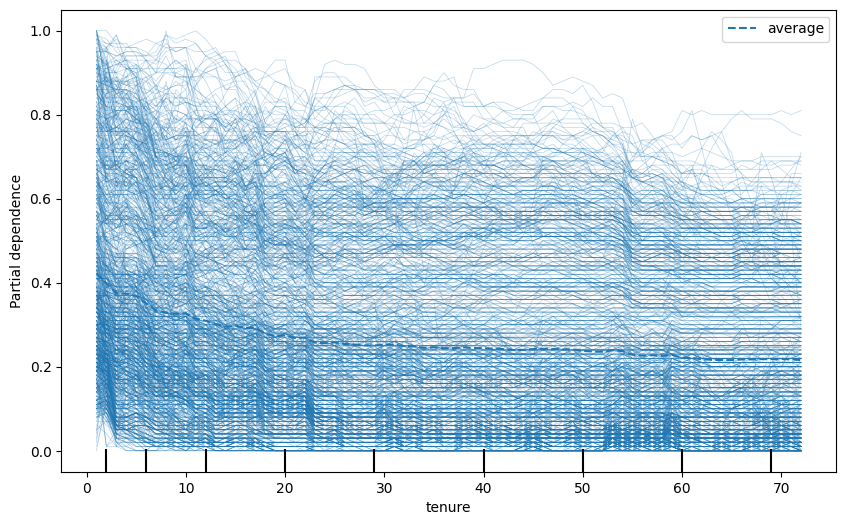

In [17]:
print ("\n Generating PDP & ICE plots.  ")
features_to_plot = "tenure" # business meaningful feature
fig ,ax = plt.subplots(figsize =(10,6))
PartialDependenceDisplay.from_estimator(model,X_train,features = [features_to_plot],kind ="both",ax =ax)
plt.show()

## 8. Permutation feature Importance ( PFI)


 Calculating perumutation feature importance ...
             Feature  Importance
4             tenure    0.107164
17    MonthlyCharges    0.102133
14          Contract    0.099911
18      TotalCharges    0.080960
8     OnlineSecurity    0.051716
16     PaymentMethod    0.051644
11       TechSupport    0.044747
15  PaperlessBilling    0.038293
0             gender    0.027467
7    InternetService    0.025422


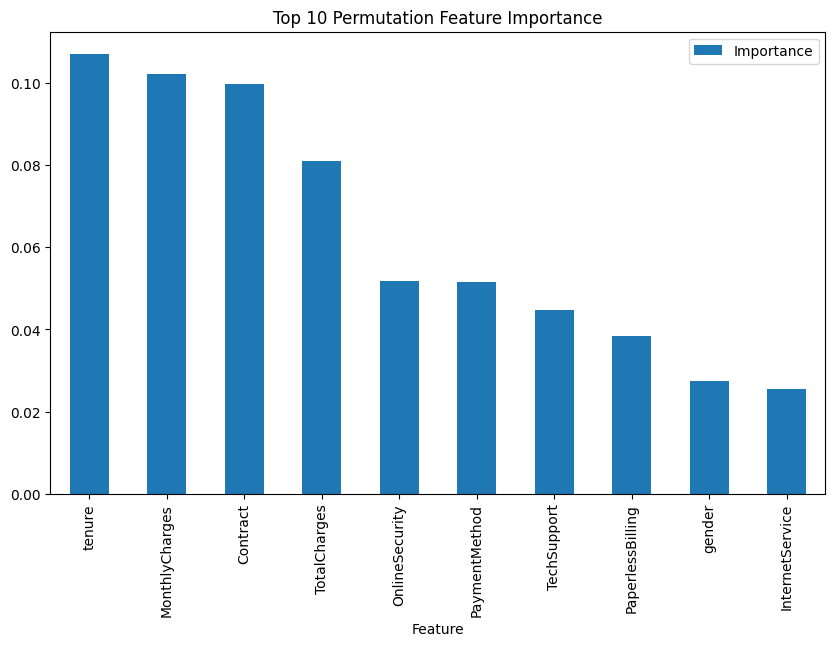

In [18]:
print("\n Calculating perumutation feature importance ...")
result = permutation_importance(model,X_train,y_train,n_repeats =10,random_state =42)
importance_df = pd.DataFrame({
    "Feature":features_names,
    "Importance" : result.importances_mean
    }).sort_values(by ='Importance', ascending = False)
print(importance_df.head(10))
importance_df.head(10).plot.bar(x ="Feature",y ="Importance",figsize =(10,6))
plt.title( "Top 10 Permutation Feature Importance")
plt.show()

## 9. LIME ( Local Interpretation)

In [23]:
print ("\n Generating LIME Explanations")
explainer = LimeTabularExplainer (training_data = np.array(X_train),
                                   feature_names = features_names,
                                   class_names = ["No Churn","Churn"],
                                   mode ="classification")



 Generating LIME Explanations


In [27]:
instance = X_test.iloc[11]
exp = explainer.explain_instance(data_row=instance,predict_fn=model.predict_proba)
exp.show_in_notebook(show_table = True)

In [28]:
instance

,11
gender,1.00
SeniorCitizen,0.00
Partner,1.00
Dependents,0.00
tenure,8.00
PhoneService,1.00
MultipleLines,0.00
InternetService,1.00
OnlineSecurity,2.00
OnlineBackup,0.00


## 10. SHAP Value

Running Shap 


100%|===================| 11239/11250 [13:00<00:00]       

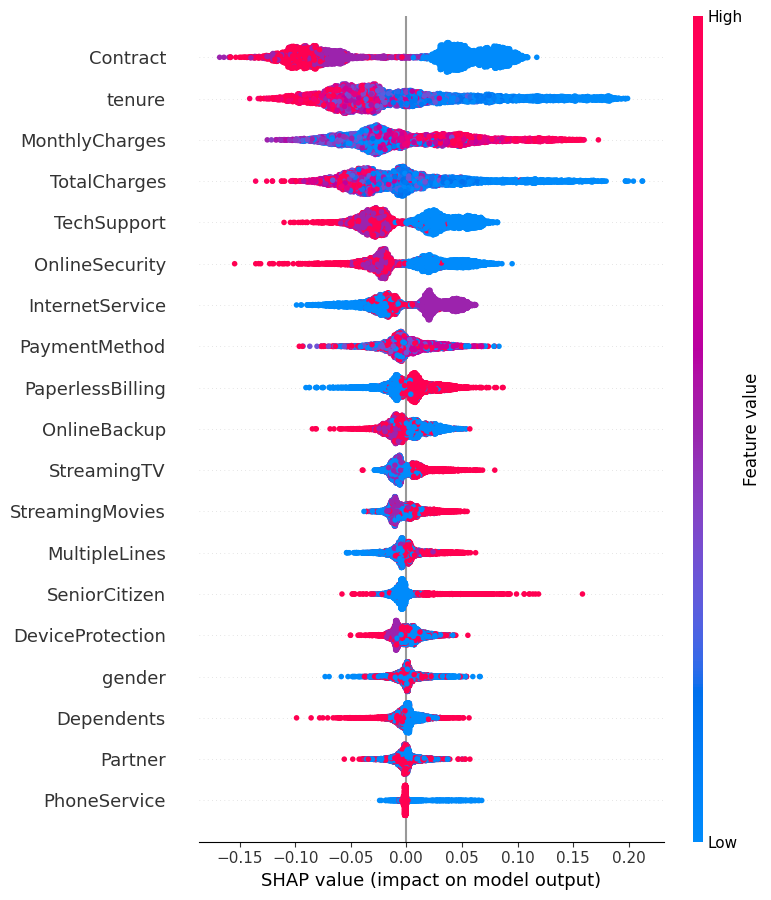

In [29]:
print ("Running Shap ")
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_train, check_additivity=False)
if len(shap_values.values.shape) ==3:
  shap_vals = shap_values.values[:,:,1]
else:
  shap_vals =shap_values.values
shap.summary_plot(shap_vals,X_train)